# 과제 - PyTorch로 mini GPT 구현

이 노트북은 과제 안내서의 구현 순서를 그대로 따릅니다.

1. 환경설정
2. NSMC 데이터 준비
3. BPE 토크나이저
4. GPTDataset / InputEmbedding
5. MultiHeadAttention
6. GPTModel
7. 사전 학습 유틸리티
8. 감성 분류 미세 조정

각 단계의 `src/` TODO를 구현한 뒤, 바로 아래 pytest 셀로 해당 단계만 확인하세요.

## 1. 환경설정

Colab에서는 GitHub 저장소 URL과 GitHub Personal Access Token을 입력해 저장소를 clone하고 `src/`를 import 경로에 추가합니다.
로컬 VS Code에서는 현재 폴더를 프로젝트 루트로 보고 실행합니다.

In [1]:
# Colab: 이 셀을 가장 먼저 실행하세요.
import os
import subprocess
import sys
from pathlib import Path


def normalize_github_url(url: str) -> str:
    """Colab 입력값을 git clone에 사용할 수 있는 https URL로 정리합니다."""
    url = url.strip()
    if not url:
        raise ValueError("GitHub 저장소 URL을 입력해야 합니다.")
    if url.startswith("github.com/"):
        url = "https://" + url
    if not url.startswith("https://"):
        raise ValueError("저장소 URL은 https://github.com/... 또는 github.com/... 형식이어야 합니다.")
    url = url.rstrip("/")
    if not url.endswith(".git"):
        url += ".git"
    return url


if "google.colab" in sys.modules:
    from getpass import getpass

    repo_url = normalize_github_url(input("GitHub 저장소 URL (예: github.com/USERNAME/gpt-lab.git): "))
    token = getpass("GitHub Personal Access Token (Private 저장소인 경우 입력, 공개 저장소면 Enter): ").strip()
    clone_url = repo_url.replace("https://", f"https://{token}@") if token else repo_url
    repo_name = Path(repo_url[:-4]).name if repo_url.endswith(".git") else Path(repo_url).name
    repo_dir = Path("/content") / repo_name

    if not repo_dir.exists():
        subprocess.run(["git", "clone", clone_url, str(repo_dir)], check=True)
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        print(f"이미 clone된 저장소를 사용합니다: {repo_dir}")

    os.chdir(repo_dir)
else:
    repo_dir = Path(".").resolve()

sys.path.insert(0, str(repo_dir / "src"))
print(f"Repo: {repo_dir}")

Repo: /Users/bruce/KraftonJungle/gpt-lab


In [2]:
# 단계별 테스트 실행 helper
import subprocess
import sys


def run_pytest(target: str):
    cmd = [sys.executable, "-m", "pytest", target, "-v"]
    print("실행 명령:", " ".join(cmd))
    result = subprocess.run(cmd, cwd=str(repo_dir), text=True, capture_output=True)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    if result.returncode != 0:
        print("\n아직 통과하지 못한 테스트가 있습니다. 해당 단계의 TODO를 먼저 구현하세요.")
    else:
        print("\n선택한 테스트를 통과했습니다.")
    return result.returncode

## 2. NSMC 데이터 준비

기본 데이터는 NAVER Sentiment Movie Corpus(NSMC)입니다.
`download_data.py`는 원본 TSV를 내려받고, 사전 학습용 텍스트와 감성 분류용 JSONL을 만듭니다.

In [3]:
from pathlib import Path

try:
    import download_data

    paths = download_data.main()
except Exception as e:
    print("데이터 준비 중 문제가 생겼습니다:", e)
    print("이미 data/ 파일이 있다면 다음 셀부터 계속 진행할 수 있습니다.")

LM_TRAIN_PATH = repo_dir / "data" / "nsmc_lm_train.txt"
LM_VAL_PATH = repo_dir / "data" / "nsmc_lm_val.txt"
print("LM train exists:", LM_TRAIN_PATH.exists(), LM_TRAIN_PATH)
print("LM val exists:", LM_VAL_PATH.exists(), LM_VAL_PATH)

다운로드 중: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
저장됨: /Users/bruce/KraftonJungle/gpt-lab/data/ratings_train.txt
다운로드 중: https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
저장됨: /Users/bruce/KraftonJungle/gpt-lab/data/ratings_test.txt
사전 학습 train 텍스트: /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_lm_train.txt (1,379,486자)
사전 학습 val 텍스트: /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_lm_val.txt (120,560자)
감성 분류 train: /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_sentiment_train.jsonl (137,996개)
감성 분류 val: /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_sentiment_val.jsonl (11,999개)
감성 분류 test: /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_sentiment_test.jsonl (49,997개)
LM train exists: True /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_lm_train.txt
LM val exists: True /Users/bruce/KraftonJungle/gpt-lab/data/nsmc_lm_val.txt


In [4]:
corpus = LM_TRAIN_PATH.read_text(encoding="utf-8") if LM_TRAIN_PATH.exists() else ""
val_corpus = LM_VAL_PATH.read_text(encoding="utf-8") if LM_VAL_PATH.exists() else ""
print("train chars:", len(corpus))
print("val chars:", len(val_corpus))
print(corpus[:200])

train chars: 1379486
val chars: 120560
개재미없다. 감독의 연출력의 한계
이제서야 보게된 대 명작 연출미가 정말 훌륭하다!!!!!!!!
소주미라클을 만들어라
귀여운 캐릭터들도 많이 나와서 보러 가야 겠어요..
블랙 코미디가 싫어요.
평점깎고싶다10글자
TV시리즈가 너무재밌어서 영화는 기대안하고 봤는데 역시....최고네요
개인적 공감이 글쎄?
시작은 니시지마 때문에 봤는데 나름 괜찮은 영화 봤다고


## 3. Step 1 - BPE 토크나이저

구현 파일: `src/bpe.py`

먼저 `pytest tests/test_bpe.py -v`를 통과시키세요. 한국어를 안전하게 다루기 위해 UTF-8 byte-level BPE로 구현해야 합니다.

In [5]:
run_pytest("tests/test_bpe.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_bpe.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 6 items

tests/test_bpe.py::TestSpecialTokens::test_special_ids_fixed PASSED      [ 16%]
tests/test_bpe.py::TestBPETokenizer::test_init_special_tokens PASSED     [ 33%]
tests/test_bpe.py::TestBPETokenizer::test_save_load_restores_vocab PASSED [ 50%]
tests/test_bpe.py::TestBPETokenizer::test_encode_decode_restores_original_text PASSED [ 66%]
tests/test_bpe.py::TestBPETokenizer::test_get_special_ids PASSED         [ 83%]
tests/test_bpe.py::TestBPETrain::test_train_increases_vocab PASSED       [100%]

============================== 6 passed in 0.01s ===============================


선택한 테스트를 통과했습니다.


0

In [6]:
# BPE 구현 후 작은 말뭉치로 인코딩/디코딩 복원을 확인합니다.
try:
    from bpe import BPETokenizer

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    sample = "이 영화는 정말 좋았다! English 123"
    ids = tokenizer.encode(sample, add_bos_eos=True)
    print(ids[:20])
    print(tokenizer.decode(ids))
except NotImplementedError as e:
    print("BPE TODO 미구현:", e)

[2, 265, 260, 290, 268, 260, 164, 153, 274, 148, 260, 166, 143, 281, 156, 270, 37, 36, 73, 114]
이 영화는 정말 좋았다! English 123


## 4. Step 2 - GPTDataset / InputEmbedding

구현 파일: `src/dataset.py`, `src/embeddings.py`

BPE가 통과한 뒤 데이터셋과 입력 임베딩을 구현합니다.

In [7]:
run_pytest("tests/test_dataset.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_dataset.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 4 items

tests/test_dataset.py::TestGPTDataset::test_dataset_length PASSED        [ 25%]
tests/test_dataset.py::TestGPTDataset::test_dataset_getitem_shape PASSED [ 50%]
tests/test_dataset.py::TestCreateDataloader::test_dataloader_batch_shape PASSED [ 75%]
tests/test_dataset.py::TestInputEmbedding::test_input_embedding_shape PASSED [100%]

============================== 4 passed in 1.81s ===============================


선택한 테스트를 통과했습니다.


0

In [8]:
try:
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from embeddings import InputEmbedding

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    emb = InputEmbedding(vocab_size=300, emb_dim=32, context_length=32, drop_rate=0.0)
    out = emb(inp)
    print(inp.shape, tgt.shape, out.shape)
except NotImplementedError as e:
    print("Dataset/Embedding TODO 미구현:", e)

torch.Size([2, 32]) torch.Size([2, 32]) torch.Size([2, 32, 32])


## 5. Step 3 - MultiHeadAttention

구현 파일: `src/attention.py`

Q/K/V shape, head 분리, causal mask를 차례로 확인하세요.

In [9]:
run_pytest("tests/test_attention.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_attention.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 2 items

tests/test_attention.py::TestMultiHeadAttention::test_mha_output_shape PASSED [ 50%]
tests/test_attention.py::TestMultiHeadAttention::test_mha_causal_mask_future_zero PASSED [100%]

============================== 2 passed in 1.12s ===============================


선택한 테스트를 통과했습니다.


0

## 6. Step 4 - GPTModel

구현 파일: `src/model.py`

LayerNorm, GELU, FeedForward, TransformerBlock, GPTModel, `generate_text_simple` 순서로 구현합니다.

In [10]:
run_pytest("tests/test_model.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_model.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 7 items

tests/test_model.py::TestLayerNorm::test_layernorm_shape PASSED          [ 14%]
tests/test_model.py::TestGELU::test_gelu_shape PASSED                    [ 28%]
tests/test_model.py::TestFeedForward::test_feedforward_shape PASSED      [ 42%]
tests/test_model.py::TestTransformerBlock::test_transformer_block_shape PASSED [ 57%]
tests/test_model.py::TestGPTModel::test_gpt_forward_shape PASSED         [ 71%]
tests/test_model.py::TestGPTModel::test_gpt_forward_with_targets_returns_loss PASSED [ 85%]
tests/test_model.py::TestGenerateTextSimple::test_generate_text_simple_shape PASSED [100%]

==================

0

In [11]:
try:
    import torch
    from model import GPTModel

    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    x = torch.randint(0, config["vocab_size"], (2, 16))
    logits = model(x)
    print(logits.shape)
except NotImplementedError as e:
    print("Model TODO 미구현:", e)

torch.Size([2, 16, 300])


## 7. Step 5 - 사전 학습 유틸리티

구현 파일: `src/train.py`

loss 계산, checkpoint 저장/로드, temperature/top-k 생성, `train_model`을 구현합니다.

In [12]:
run_pytest("tests/test_train.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_train.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 5 items

tests/test_train.py::TestCalcLossBatch::test_calc_loss_batch_returns_scalar PASSED [ 20%]
tests/test_train.py::TestCalcLossLoader::test_calc_loss_loader_returns_float PASSED [ 40%]
tests/test_train.py::TestCheckpoint::test_save_load_checkpoint_restores_epoch_and_step PASSED [ 60%]
tests/test_train.py::TestGenerate::test_generate_shape PASSED            [ 80%]
tests/test_train.py::TestPlotLosses::test_plot_losses_callable PASSED    [100%]

=============================== warnings summary ===============================
tests/test_train.py::TestPlotLosses::test_plot_losses_callable
  /Users/bruce/Krafto

0

In [13]:
# 모든 앞 단계가 구현된 뒤 한 배치 smoke test를 실행합니다.
try:
    import torch
    from bpe import BPETokenizer
    from dataset import create_dataloader
    from model import GPTModel
    from train import calc_loss_batch

    tokenizer = BPETokenizer(vocab_size=300)
    tokenizer.train(corpus[:5000])
    token_ids = tokenizer.encode(corpus[:5000])
    loader = create_dataloader(token_ids, context_length=32, batch_size=2, shuffle=False)
    inp, tgt = next(iter(loader))
    config = {
        "vocab_size": 300,
        "context_length": 32,
        "emb_dim": 32,
        "n_heads": 4,
        "n_layers": 1,
        "drop_rate": 0.0,
        "qkv_bias": False,
    }
    model = GPTModel(config)
    loss = calc_loss_batch(inp, tgt, model, torch.device("cpu"))
    loss.backward()
    print("smoke loss:", loss.item())
except NotImplementedError as e:
    print("사전 학습 TODO 미구현:", e)

smoke loss: 5.860545635223389


## 8. Step 6 - 감성 분류 미세 조정

구현 파일: `src/finetune.py`

NSMC JSONL/TSV를 읽어 분류 Dataset을 만들고, GPT backbone 위에 classification head를 붙입니다.

In [14]:
run_pytest("tests/test_finetune.py")

실행 명령: /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python -m pytest tests/test_finetune.py -v
============================= test session starts ==============================
platform darwin -- Python 3.11.10, pytest-9.0.3, pluggy-1.6.0 -- /Users/bruce/KraftonJungle/gpt-lab/.venv/bin/python
cachedir: .pytest_cache
rootdir: /Users/bruce/KraftonJungle/gpt-lab
collecting ... collected 4 items

tests/test_finetune.py::TestMakeSentimentDataset::test_make_sentiment_dataset_splits_rows PASSED [ 25%]
tests/test_finetune.py::TestReviewSentimentDataset::test_review_sentiment_dataset_getitem PASSED [ 50%]
tests/test_finetune.py::TestGPTForSequenceClassification::test_sequence_classification_shape PASSED [ 75%]
tests/test_finetune.py::TestSentimentTrainEval::test_train_eval_functions_exist PASSED [100%]

============================== 4 passed in 1.09s ===============================


선택한 테스트를 통과했습니다.


0

## 9. 전체 테스트와 제출 전 확인

각 단계 테스트가 모두 통과하면 마지막에 전체 테스트를 실행합니다.

In [ ]:
run_pytest("tests/")

### 재사용 가능한 사전 학습 준비 코드

BPE vocabulary는 매번 다시 학습하지 않고, 한 번 저장한 뒤 다음 실행부터 `load()`해서 재사용합니다.

In [43]:
# 기존 실행 셀에 의존하지 않는 재사용용 준비 코드입니다.
# BPE vocab이 있으면 load하고, 없을 때만 train한 뒤 저장합니다.

import sys
from pathlib import Path

import torch

base_dir = Path(repo_dir).resolve() if "repo_dir" in globals() else Path(".").resolve()
src_dir = base_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from bpe import BPETokenizer
from dataset import create_dataloader

DATA_DIR = base_dir / "data"
LM_TRAIN_PATH = DATA_DIR / "nsmc_lm_train.txt"
LM_VAL_PATH = DATA_DIR / "nsmc_lm_val.txt"

BPE_TRAIN_CHARS = 1_000_000
BPE_VOCAB_SIZE = 3_000
CONTEXT_LENGTH = 128
BATCH_SIZE = 8
STRIDE = CONTEXT_LENGTH

VOCAB_PATH = DATA_DIR / f"vocab_nsmc_chars{BPE_TRAIN_CHARS}_vocab{BPE_VOCAB_SIZE}.json"


def load_or_train_bpe() -> BPETokenizer:
    tokenizer = BPETokenizer(vocab_size=BPE_VOCAB_SIZE)

    if VOCAB_PATH.exists():
        tokenizer.load(VOCAB_PATH)
        print(f"BPE vocab loaded: {VOCAB_PATH}")
        return tokenizer

    train_text = LM_TRAIN_PATH.read_text(encoding="utf-8")
    tokenizer.train(train_text[:BPE_TRAIN_CHARS])
    tokenizer.save(VOCAB_PATH)
    print(f"BPE vocab trained and saved: {VOCAB_PATH}")
    return tokenizer


def build_lm_dataloaders(tokenizer: BPETokenizer):
    train_text = LM_TRAIN_PATH.read_text(encoding="utf-8")
    val_text = LM_VAL_PATH.read_text(encoding="utf-8")

    train_token_ids = tokenizer.encode(train_text)
    val_token_ids = tokenizer.encode(val_text)

    train_loader = create_dataloader(
        train_token_ids,
        context_length=CONTEXT_LENGTH,
        batch_size=BATCH_SIZE,
        stride=STRIDE,
        drop_last=True,
        shuffle=True,
    )
    val_loader = create_dataloader(
        val_token_ids,
        context_length=CONTEXT_LENGTH,
        batch_size=BATCH_SIZE,
        stride=STRIDE,
        drop_last=False,
        shuffle=False,
    )
    return train_loader, val_loader, train_token_ids, val_token_ids


tokenizer = load_or_train_bpe()
train_loader, val_loader, train_token_ids, val_token_ids = build_lm_dataloaders(tokenizer)

GPT_CONFIG = {
    "vocab_size": max(tokenizer.id_to_token) + 1,
    "context_length": CONTEXT_LENGTH,
    "emb_dim": 192,
    "n_heads": 4,
    "n_layers": 4,
    "drop_rate": 0.3,
    "qkv_bias": False,
}

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)
print("vocab size:", GPT_CONFIG["vocab_size"])
print("train tokens:", len(train_token_ids), "/ val tokens:", len(val_token_ids))
print("train batches:", len(train_loader), "/ val batches:", len(val_loader))

BPE vocab loaded: /Users/bruce/KraftonJungle/gpt-lab/data/vocab_nsmc_chars1000000_vocab3000.json
device: mps
vocab size: 3000
train tokens: 805379 / val tokens: 70426
train batches: 786 / val batches: 69


In [44]:
# GPT 모델 뼈대를 실제 PyTorch module로 구성합니다.
# 이 셀은 학습을 하지 않고, 모델 구조와 forward 출력 shape만 확인합니다.

import importlib

import model as model_module
importlib.reload(model_module)

from model import GPTModel

model = GPTModel(GPT_CONFIG).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("GPT_CONFIG:", GPT_CONFIG)
print(f"total params: {total_params:,}")
print(f"trainable params: {trainable_params:,}")

# 한 batch를 넣어 logits shape를 확인합니다.
model.eval()
input_batch, target_batch = next(iter(train_loader))

with torch.no_grad():
    logits = model(input_batch.to(device))

print("input_batch shape:", tuple(input_batch.shape))
print("target_batch shape:", tuple(target_batch.shape))
print("logits shape:", tuple(logits.shape))

model.train()

GPT_CONFIG: {'vocab_size': 3000, 'context_length': 128, 'emb_dim': 192, 'n_heads': 4, 'n_layers': 4, 'drop_rate': 0.3, 'qkv_bias': False}
total params: 2,954,112
trainable params: 2,954,112
input_batch shape: (8, 128)
target_batch shape: (8, 128)
logits shape: (8, 128, 3000)


GPTModel(
  (embedding): InputEmbedding(
    (token_embedding): Embedding(3000, 192)
    (position_embedding): Embedding(128, 192)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=192, out_features=192, bias=False)
        (k_proj): Linear(in_features=192, out_features=192, bias=False)
        (v_proj): Linear(in_features=192, out_features=192, bias=False)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): GELU()
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.3, inplace=False)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (dropout): Dropout(p=0.3, inplace=False)
    )
  

step 0: train loss 8.1720, val loss 8.1678, train ppl 3540.55, val ppl 3525.72, lr 0.0003
step 100: train loss 7.3292, val loss 7.3079, train ppl 1524.24, val ppl 1492.07, lr 0.000299987
step 200: train loss 7.2992, val loss 7.2981, train ppl 1479.09, val ppl 1477.49, lr 0.000299947
step 300: train loss 7.3090, val loss 7.2938, train ppl 1493.71, val ppl 1471.22, lr 0.00029988
step 400: train loss 7.3013, val loss 7.2969, train ppl 1482.24, val ppl 1475.68, lr 0.000299787
step 500: train loss 7.2975, val loss 7.2909, train ppl 1476.66, val ppl 1466.92, lr 0.000299667
step 600: train loss 7.2878, val loss 7.2847, train ppl 1462.34, val ppl 1457.76, lr 0.000299521
step 700: train loss 7.2655, val loss 7.2645, train ppl 1430.07, val ppl 1428.74, lr 0.000299348
step 800: train loss 7.1962, val loss 7.2144, train ppl 1334.37, val ppl 1358.79, lr 0.000299149
step 900: train loss 7.1297, val loss 7.1456, train ppl 1248.49, val ppl 1268.45, lr 0.000298923
step 1000: train loss 7.0216, val loss

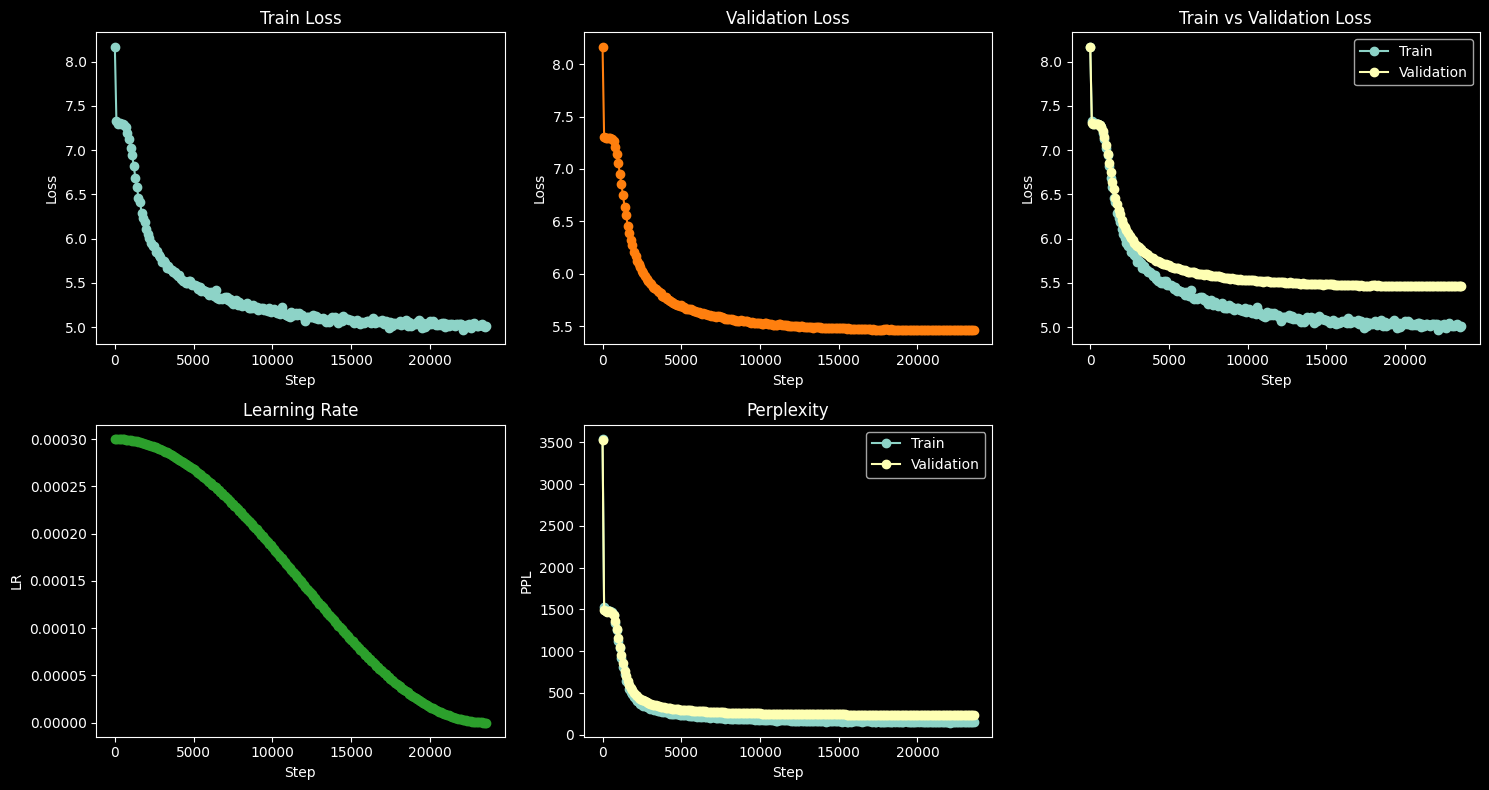

checkpoint saved: /Users/bruce/KraftonJungle/gpt-lab/checkpoints/pretrain_vocab3000_ctx128_epoch30.pt
sample generation:
이 영화보고나서 본 영화 중반개중 최고!
진짜.. 정말 재미있어요...정말 재밌었음!
오늘 본사람의 유발이냐?
기대안돼지, 이런 쓰레기 영화!
와...

=== Pretraining Run Summary ===
BPE train chars      : 1,000,000
BPE vocab size       : 3,000
Actual vocab size    : 3,000
Context length       : 128
Batch size           : 8
Stride               : 128
Embedding dim        : 192
Attention heads      : 4
Transformer layers   : 4
Drop rate            : 0.3
QKV bias             : False
Learning rate        : 0.0003
Weight decay         : 0.03
Scheduler            : CosineAnnealingLR
Epochs               : 30
Total steps          : 23580
Eval frequency       : every 100 steps
Eval batches         : 20
Final train loss     : 5.0111
Final val loss       : 5.4645
Final train PPL      : 150.07
Final val PPL        : 236.15
Checkpoint path      : /Users/bruce/KraftonJungle/gpt-lab/checkpoints/pretrain_vocab3000_ctx128_epoch30.pt


In [45]:
# 사전학습을 실행하고, 주요 그래프용 지표를 기록합니다.
# 기록하는 그래프: train loss, validation loss, train/val 비교, learning rate, perplexity.

import importlib
import math

import matplotlib.pyplot as plt
import torch

import train as train_module
importlib.reload(train_module)

from train import calc_loss_loader, generate_and_print_sample, save_checkpoint

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.03
NUM_EPOCHS = 30
EVAL_FREQ = 100
EVAL_ITER = 20
START_CONTEXT = "이 영화"


def to_perplexity(loss: float) -> float:
    return math.exp(loss) if loss < 20 else float("inf")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, total_steps),
)

history = {
    "step": [],
    "train_loss": [],
    "val_loss": [],
    "lr": [],
    "train_ppl": [],
    "val_ppl": [],
}


def record_metrics(step: int) -> None:
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=EVAL_ITER)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=EVAL_ITER)
    lr = optimizer.param_groups[0]["lr"]

    history["step"].append(step)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(lr)
    history["train_ppl"].append(to_perplexity(train_loss))
    history["val_ppl"].append(to_perplexity(val_loss))

    print(
        f"step {step}: "
        f"train loss {train_loss:.4f}, val loss {val_loss:.4f}, "
        f"train ppl {history['train_ppl'][-1]:.2f}, val ppl {history['val_ppl'][-1]:.2f}, "
        f"lr {lr:.6g}"
    )


global_step = 0
record_metrics(global_step)

model.to(device)
for epoch in range(NUM_EPOCHS):
    model.train()

    for input_batch, target_batch in train_loader:
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()
        loss, _ = model(input_batch, targets=target_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()

        global_step += 1

        if global_step % EVAL_FREQ == 0 or global_step == total_steps:
            record_metrics(global_step)

print("pretraining finished")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
steps = history["step"]

axes[0, 0].plot(steps, history["train_loss"], marker="o")
axes[0, 0].set_title("Train Loss")
axes[0, 0].set_xlabel("Step")
axes[0, 0].set_ylabel("Loss")

axes[0, 1].plot(steps, history["val_loss"], marker="o", color="tab:orange")
axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Step")
axes[0, 1].set_ylabel("Loss")

axes[0, 2].plot(steps, history["train_loss"], marker="o", label="Train")
axes[0, 2].plot(steps, history["val_loss"], marker="o", label="Validation")
axes[0, 2].set_title("Train vs Validation Loss")
axes[0, 2].set_xlabel("Step")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].legend()

axes[1, 0].plot(steps, history["lr"], marker="o", color="tab:green")
axes[1, 0].set_title("Learning Rate")
axes[1, 0].set_xlabel("Step")
axes[1, 0].set_ylabel("LR")

axes[1, 1].plot(steps, history["train_ppl"], marker="o", label="Train")
axes[1, 1].plot(steps, history["val_ppl"], marker="o", label="Validation")
axes[1, 1].set_title("Perplexity")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("PPL")
axes[1, 1].legend()

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

CKPT_DIR = base_dir / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = CKPT_DIR / (
    f"pretrain_vocab{GPT_CONFIG['vocab_size']}_ctx{GPT_CONFIG['context_length']}_epoch{NUM_EPOCHS}.pt"
)
save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=NUM_EPOCHS,
    global_step=global_step,
    path=str(ckpt_path),
)
print(f"checkpoint saved: {ckpt_path}")

print("sample generation:")
generate_and_print_sample(
    model=model,
    tokenizer=tokenizer,
    device=device,
    start_context=START_CONTEXT,
    max_new_tokens=40,
    context_size=GPT_CONFIG["context_length"],
    temperature=0.8,
    top_k=40,
)

print("\n=== Pretraining Run Summary ===")
print(f"BPE train chars      : {BPE_TRAIN_CHARS:,}")
print(f"BPE vocab size       : {BPE_VOCAB_SIZE:,}")
print(f"Actual vocab size    : {GPT_CONFIG['vocab_size']:,}")
print(f"Context length       : {GPT_CONFIG['context_length']}")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Stride               : {STRIDE}")
print(f"Embedding dim        : {GPT_CONFIG['emb_dim']}")
print(f"Attention heads      : {GPT_CONFIG['n_heads']}")
print(f"Transformer layers   : {GPT_CONFIG['n_layers']}")
print(f"Drop rate            : {GPT_CONFIG['drop_rate']}")
print(f"QKV bias             : {GPT_CONFIG['qkv_bias']}")
print(f"Learning rate        : {LEARNING_RATE}")
print(f"Weight decay         : {WEIGHT_DECAY}")
print(f"Scheduler            : CosineAnnealingLR")
print(f"Epochs               : {NUM_EPOCHS}")
print(f"Total steps          : {global_step}")
print(f"Eval frequency       : every {EVAL_FREQ} steps")
print(f"Eval batches         : {EVAL_ITER}")
print(f"Final train loss     : {history['train_loss'][-1]:.4f}")
print(f"Final val loss       : {history['val_loss'][-1]:.4f}")
print(f"Final train PPL      : {history['train_ppl'][-1]:.2f}")
print(f"Final val PPL        : {history['val_ppl'][-1]:.2f}")
print(f"Checkpoint path      : {ckpt_path}")

### 감성 분류 미세 조정 실행 코드

사전학습된 GPT backbone 위에 분류 head를 붙이고, NSMC 긍정/부정 분류로 미세 조정합니다.

epoch 1: train loss 0.6939, train acc 0.5648, val loss 0.6508, val acc 0.6073
epoch 2: train loss 0.5988, train acc 0.6730, val loss 0.5602, val acc 0.7063
epoch 3: train loss 0.5429, train acc 0.7193, val loss 0.5261, val acc 0.7403
epoch 4: train loss 0.5092, train acc 0.7513, val loss 0.5139, val acc 0.7517
epoch 5: train loss 0.4757, train acc 0.7724, val loss 0.5185, val acc 0.7593
epoch 6: train loss 0.4524, train acc 0.7879, val loss 0.5429, val acc 0.7493
epoch 7: train loss 0.4314, train acc 0.8002, val loss 0.5128, val acc 0.7693
epoch 8: train loss 0.4141, train acc 0.8112, val loss 0.5256, val acc 0.7777
epoch 9: train loss 0.3990, train acc 0.8217, val loss 0.5040, val acc 0.7773
epoch 10: train loss 0.3780, train acc 0.8325, val loss 0.5430, val acc 0.7803
test loss 0.5082, test acc 0.7863


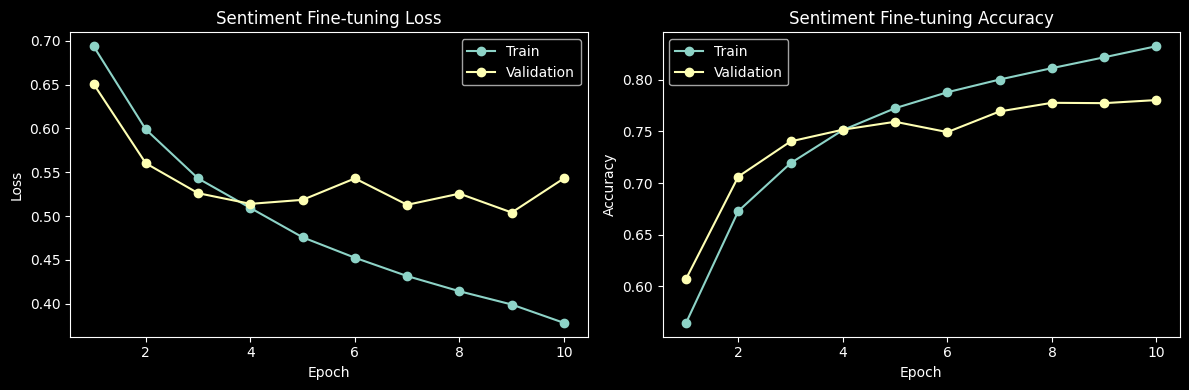

sample sentiment predictions:
- positive (0.998) :: 이 영화 정말 재미있고 감동적이었다
- negative (0.991) :: 시간이 아까울 정도로 지루했다
- negative (0.956) :: 배우 연기는 좋았지만 이야기는 별로였다

=== Sentiment Fine-tuning Summary ===
Train samples        : 20,000
Validation samples   : 3,000
Test samples         : 3,000
Max length           : 128
Batch size           : 16
Epochs               : 10
Backbone LR          : 3e-05
Classifier LR        : 0.0005
Weight decay         : 0.01
Drop rate            : 0.2
Freeze backbone      : False
Final train loss     : 0.3780
Final train acc      : 0.8325
Final val loss       : 0.5430
Final val acc        : 0.7803
Test loss            : 0.5082
Test acc             : 0.7863
Checkpoint path      : /Users/bruce/KraftonJungle/gpt-lab/checkpoints/sentiment_vocab3000_ctx128_epoch10.pt


In [41]:
# 감성 분류 미세 조정을 실행합니다.
# 현재 메모리에 있는 사전학습 model/tokenizer를 사용합니다.

import importlib
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import finetune as finetune_module
importlib.reload(finetune_module)

from finetune import (
    GPTForSequenceClassification,
    ReviewSentimentDataset,
    evaluate_sentiment,
    train_epoch_sentiment,
)

base_dir = Path(repo_dir).resolve() if "repo_dir" in globals() else Path(".").resolve()
DATA_DIR = base_dir / "data"
CKPT_DIR = base_dir / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

SENTIMENT_TRAIN_PATH = DATA_DIR / "nsmc_sentiment_train.jsonl"
SENTIMENT_VAL_PATH = DATA_DIR / "nsmc_sentiment_val.jsonl"
SENTIMENT_TEST_PATH = DATA_DIR / "nsmc_sentiment_test.jsonl"

FINETUNE_SEED = 42
FINETUNE_TRAIN_SAMPLES = 20_000
FINETUNE_VAL_SAMPLES = 3_000
FINETUNE_TEST_SAMPLES = 3_000
FINETUNE_MAX_LENGTH = GPT_CONFIG["context_length"]
FINETUNE_BATCH_SIZE = 16
FINETUNE_EPOCHS = 10
BACKBONE_LR = 3e-5
CLASSIFIER_LR = 5e-4
FINETUNE_WEIGHT_DECAY = 0.01
FINETUNE_DROP_RATE = 0.2
FREEZE_BACKBONE = False


def read_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows


def sample_rows(rows: list[dict], limit: int | None, seed: int) -> list[dict]:
    rows = list(rows)
    random.Random(seed).shuffle(rows)
    return rows if limit is None else rows[:limit]


train_rows = sample_rows(read_jsonl(SENTIMENT_TRAIN_PATH), FINETUNE_TRAIN_SAMPLES, FINETUNE_SEED)
val_rows = sample_rows(read_jsonl(SENTIMENT_VAL_PATH), FINETUNE_VAL_SAMPLES, FINETUNE_SEED)
test_rows = sample_rows(read_jsonl(SENTIMENT_TEST_PATH), FINETUNE_TEST_SAMPLES, FINETUNE_SEED)

train_ds_cls = ReviewSentimentDataset(
    train_rows,
    tokenizer,
    max_length=FINETUNE_MAX_LENGTH,
)
val_ds_cls = ReviewSentimentDataset(
    val_rows,
    tokenizer,
    max_length=FINETUNE_MAX_LENGTH,
)
test_ds_cls = ReviewSentimentDataset(
    test_rows,
    tokenizer,
    max_length=FINETUNE_MAX_LENGTH,
)

train_loader_cls = DataLoader(
    train_ds_cls,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
val_loader_cls = DataLoader(
    val_ds_cls,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)
test_loader_cls = DataLoader(
    test_ds_cls,
    batch_size=FINETUNE_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

classification_model = GPTForSequenceClassification(
    model,
    num_labels=2,
    drop_rate=FINETUNE_DROP_RATE,
).to(device)

if FREEZE_BACKBONE:
    for param in classification_model.gpt.parameters():
        param.requires_grad = False

if FREEZE_BACKBONE:
    optimizer_cls = torch.optim.AdamW(
        classification_model.classifier.parameters(),
        lr=CLASSIFIER_LR,
        weight_decay=FINETUNE_WEIGHT_DECAY,
    )
else:
    optimizer_cls = torch.optim.AdamW(
        [
            {"params": classification_model.gpt.parameters(), "lr": BACKBONE_LR},
            {"params": classification_model.classifier.parameters(), "lr": CLASSIFIER_LR},
        ],
        weight_decay=FINETUNE_WEIGHT_DECAY,
    )

finetune_history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

for epoch in range(1, FINETUNE_EPOCHS + 1):
    train_loss, train_acc = train_epoch_sentiment(
        classification_model,
        train_loader_cls,
        optimizer_cls,
        device,
    )
    val_loss, val_acc = evaluate_sentiment(
        classification_model,
        val_loader_cls,
        device,
    )

    finetune_history["epoch"].append(epoch)
    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_acc"].append(train_acc)
    finetune_history["val_loss"].append(val_loss)
    finetune_history["val_acc"].append(val_acc)

    print(
        f"epoch {epoch}: "
        f"train loss {train_loss:.4f}, train acc {train_acc:.4f}, "
        f"val loss {val_loss:.4f}, val acc {val_acc:.4f}"
    )

test_loss, test_acc = evaluate_sentiment(
    classification_model,
    test_loader_cls,
    device,
)
print(f"test loss {test_loss:.4f}, test acc {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = finetune_history["epoch"]

axes[0].plot(epochs, finetune_history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, finetune_history["val_loss"], marker="o", label="Validation")
axes[0].set_title("Sentiment Fine-tuning Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epochs, finetune_history["train_acc"], marker="o", label="Train")
axes[1].plot(epochs, finetune_history["val_acc"], marker="o", label="Validation")
axes[1].set_title("Sentiment Fine-tuning Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


def predict_sentiment(texts: list[str]) -> list[tuple[str, str, float]]:
    classification_model.eval()
    results = []
    with torch.no_grad():
        for text in texts:
            token_ids = tokenizer.encode(text, add_bos_eos=True)[:FINETUNE_MAX_LENGTH]
            if len(token_ids) < FINETUNE_MAX_LENGTH:
                token_ids += [tokenizer.get_pad_id()] * (FINETUNE_MAX_LENGTH - len(token_ids))
            input_ids = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)
            logits = classification_model(input_ids)
            probs = torch.softmax(logits, dim=-1)[0]
            pred = int(torch.argmax(probs).item())
            label = "positive" if pred == 1 else "negative"
            results.append((text, label, float(probs[pred].item())))
    return results


sample_reviews = [
    "이 영화 정말 재미있고 감동적이었다",
    "시간이 아까울 정도로 지루했다",
    "배우 연기는 좋았지만 이야기는 별로였다",
]

print("sample sentiment predictions:")
for text, label, prob in predict_sentiment(sample_reviews):
    print(f"- {label} ({prob:.3f}) :: {text}")

finetune_ckpt_path = CKPT_DIR / (
    f"sentiment_vocab{GPT_CONFIG['vocab_size']}_ctx{GPT_CONFIG['context_length']}_epoch{FINETUNE_EPOCHS}.pt"
)
torch.save(
    {
        "classification_model_state_dict": classification_model.state_dict(),
        "model_config": GPT_CONFIG,
        "finetune_config": {
            "train_samples": len(train_rows),
            "val_samples": len(val_rows),
            "test_samples": len(test_rows),
            "max_length": FINETUNE_MAX_LENGTH,
            "batch_size": FINETUNE_BATCH_SIZE,
            "num_epochs": FINETUNE_EPOCHS,
            "backbone_lr": BACKBONE_LR,
            "classifier_lr": CLASSIFIER_LR,
            "weight_decay": FINETUNE_WEIGHT_DECAY,
            "drop_rate": FINETUNE_DROP_RATE,
            "freeze_backbone": FREEZE_BACKBONE,
            "seed": FINETUNE_SEED,
        },
        "history": finetune_history,
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "pretrain_checkpoint": str(ckpt_path) if "ckpt_path" in globals() else None,
    },
    finetune_ckpt_path,
)

print("\n=== Sentiment Fine-tuning Summary ===")
print(f"Train samples        : {len(train_rows):,}")
print(f"Validation samples   : {len(val_rows):,}")
print(f"Test samples         : {len(test_rows):,}")
print(f"Max length           : {FINETUNE_MAX_LENGTH}")
print(f"Batch size           : {FINETUNE_BATCH_SIZE}")
print(f"Epochs               : {FINETUNE_EPOCHS}")
print(f"Backbone LR          : {BACKBONE_LR}")
print(f"Classifier LR        : {CLASSIFIER_LR}")
print(f"Weight decay         : {FINETUNE_WEIGHT_DECAY}")
print(f"Drop rate            : {FINETUNE_DROP_RATE}")
print(f"Freeze backbone      : {FREEZE_BACKBONE}")
print(f"Final train loss     : {finetune_history['train_loss'][-1]:.4f}")
print(f"Final train acc      : {finetune_history['train_acc'][-1]:.4f}")
print(f"Final val loss       : {finetune_history['val_loss'][-1]:.4f}")
print(f"Final val acc        : {finetune_history['val_acc'][-1]:.4f}")
print(f"Test loss            : {test_loss:.4f}")
print(f"Test acc             : {test_acc:.4f}")
print(f"Checkpoint path      : {finetune_ckpt_path}")